In [1]:
import ccxt
import pandas as pd
import numpy as np
import time

# 1. CONFIGURACIÓN
exchange = ccxt.binance()
TIMEFRAME = '15m' # Velas de 15 minutos (Ritmo medio-alto)
PAIRS = ['BTC/USDT', 'SOL/USDT']
SINCE = exchange.parse8601('2023-01-01T00:00:00Z') # Desde 2023

def fetch_history(symbol, timeframe, since):
    print(f"Descargando {symbol} desde 2023...")
    all_ohlcv = []
    
    while since < exchange.milliseconds():
        try:
            ohlcv = exchange.fetch_ohlcv(symbol, timeframe, since=since, limit=1000)
            if not ohlcv: break
            
            all_ohlcv.extend(ohlcv)
            since = ohlcv[-1][0] + 1 # Actualizar tiempo para la siguiente página
            
            # Pequeña pausa para no saturar la API (Rate Limit)
            time.sleep(0.1)
            
            # Progreso visual
            last_date = pd.to_datetime(ohlcv[-1][0], unit='ms')
            print(f"   -> Bajado hasta: {last_date}")
            
        except Exception as e:
            print(f"Error: {e}")
            break
            
    df = pd.DataFrame(all_ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('timestamp', inplace=True)
    return df[['close', 'volume']] # Nos quedamos precio y volumen

# 2. DESCARGA
btc = fetch_history('BTC/USDT', TIMEFRAME, SINCE)
sol = fetch_history('SOL/USDT', TIMEFRAME, SINCE)

# 3. FUSIÓN Y LIMPIEZA
print("\nAlineando datos...")
df = pd.concat([btc, sol], axis=1).dropna()
# Renombramos columnas para no liarnos (Close y Volume de cada uno)
df.columns = ['BTC', 'Vol_BTC', 'SOL', 'Vol_SOL']

# 4. FEATURE ENGINEERING (Física del Mercado)
print("Calculando indicadores...")

# Retornos
df['lret_btc'] = np.log(df['BTC'] / df['BTC'].shift(1))
df['lret_sol'] = np.log(df['SOL'] / df['SOL'].shift(1))

# Volumen Relativo (Cambio de volumen)
df['vol_change_btc'] = np.log(df['Vol_BTC'] / df['Vol_BTC'].shift(1) + 1) # +1 para evitar log(0)
df['vol_change_sol'] = np.log(df['Vol_SOL'] / df['Vol_SOL'].shift(1) + 1)

# El Ratio y su Z-Score (La señal principal)
df['ratio'] = df['SOL'] / df['BTC']

# Ventana más larga porque 15m es ruidoso (usamos 24h = 4 * 24 = 96 periodos)
WINDOW = 96 
df['ratio_mean'] = df['ratio'].rolling(window=WINDOW).mean()
df['ratio_std'] = df['ratio'].rolling(window=WINDOW).std()
df['z_score'] = (df['ratio'] - df['ratio_mean']) / df['ratio_std']

# Target: ¿Subirá el ratio en las próximas 4 velas (1 hora)?
PREDICTION_HORIZON = 4 
df['future_ratio'] = df['ratio'].shift(-PREDICTION_HORIZON)
# Target 1 si sube, 0 si baja
df['Target'] = (df['future_ratio'] > df['ratio']).astype(int)

# Limpieza final
df = df.dropna()

print(f"\nDataset Final: {len(df)} velas de 15 min.")
print(df.head())

# Guardar
df.to_csv('datos_crypto_sol_btc_15m.csv')
print("Guardado en 'datos_crypto_sol_btc_15m.csv'")

Descargando BTC/USDT desde 2023...
   -> Bajado hasta: 2023-01-11 09:45:00
   -> Bajado hasta: 2023-01-21 19:45:00
   -> Bajado hasta: 2023-02-01 05:45:00
   -> Bajado hasta: 2023-02-11 15:45:00
   -> Bajado hasta: 2023-02-22 01:45:00
   -> Bajado hasta: 2023-03-04 11:45:00
   -> Bajado hasta: 2023-03-14 21:45:00
   -> Bajado hasta: 2023-03-25 09:00:00
   -> Bajado hasta: 2023-04-04 19:00:00
   -> Bajado hasta: 2023-04-15 05:00:00
   -> Bajado hasta: 2023-04-25 15:00:00
   -> Bajado hasta: 2023-05-06 01:00:00
   -> Bajado hasta: 2023-05-16 11:00:00
   -> Bajado hasta: 2023-05-26 21:00:00
   -> Bajado hasta: 2023-06-06 07:00:00
   -> Bajado hasta: 2023-06-16 17:00:00
   -> Bajado hasta: 2023-06-27 03:00:00
   -> Bajado hasta: 2023-07-07 13:00:00
   -> Bajado hasta: 2023-07-17 23:00:00
   -> Bajado hasta: 2023-07-28 09:00:00
   -> Bajado hasta: 2023-08-07 19:00:00
   -> Bajado hasta: 2023-08-18 05:00:00
   -> Bajado hasta: 2023-08-28 15:00:00
   -> Bajado hasta: 2023-09-08 01:00:00
   ->

Cargando datos...

Iniciando entrenamiento V2 (Target: SOL Price)...
Epoch 1 | Train: 0.6918 | Val: 0.6936
Epoch 2 | Train: 0.6915 | Val: 0.6952
Epoch 3 | Train: 0.6911 | Val: 0.6940
Epoch 4 | Train: 0.6909 | Val: 0.6941
Epoch 5 | Train: 0.6906 | Val: 0.6945
Epoch 6 | Train: 0.6902 | Val: 0.6956
Early Stopping.

--- BACKTEST SOL/USDT ---


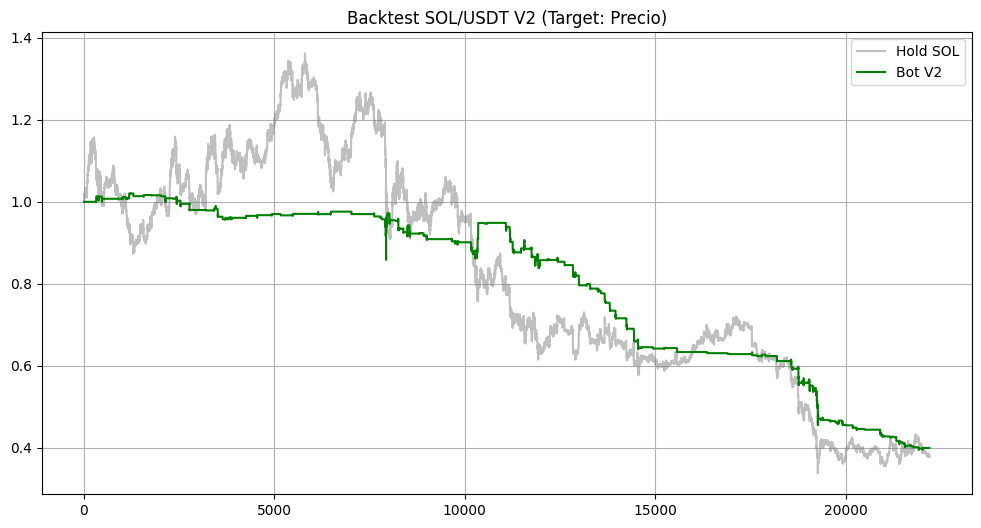

Retorno Bot: -60.06%


In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import joblib

# --- 1. CONFIGURACIÓN ---
FILE_NAME = 'datos_crypto_sol_btc_15m.csv'
MODEL_NAME = 'modelo_crypto_sol_v2.pth'
SCALER_NAME = 'scaler_crypto_v2.pkl'

# Parámetros Ajustados
WINDOW_SIZE = 96      
INPUT_DIM = 7         # Añadimos RSI (ahora son 7 features)
HIDDEN_DIM = 64       
NUM_LAYERS = 2        # Subimos a 2 capas para captar patrones más complejos
DROPOUT_RATE = 0.2    # Bajamos dropout (0.5 era excesivo y causó underfitting)

BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 30           

# --- 2. PREPARACIÓN DE DATOS ---
print("Cargando datos...")
df = pd.read_csv(FILE_NAME, index_col=0, parse_dates=True)

# Limpieza inicial de infinitos
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# === AÑADIR RSI (Indicador de Fuerza) ===
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['rsi'] = calculate_rsi(df['SOL'])
# ========================================

# Limpiamos NaNs generados por RSI
df = df.dropna()

# DEFINIR EL TARGET CORRECTO (DIRECCIONAL)
# Queremos predecir si SOL subirá en Dólares, no el Ratio.
PREDICTION_HORIZON = 4 # 1 hora
df['future_sol'] = df['SOL'].shift(-PREDICTION_HORIZON)
df['Target'] = (df['future_sol'] > df['SOL']).astype(int)

df = df.dropna()

# Features (Inputs) - BTC sigue siendo clave como predictor
features = ['lret_btc', 'lret_sol', 'vol_change_btc', 'vol_change_sol', 'ratio', 'z_score', 'rsi']
target = 'Target'

X = df[features].values
y = df[target].values

# Limpieza de seguridad final
if not np.isfinite(X).all(): X = np.nan_to_num(X)

# División Temporal
split_idx = int(len(X) * 0.8)
X_train_raw = X[:split_idx]
X_test_raw = X[split_idx:]
y_train = y[:split_idx]
y_test = y[split_idx:]

# Escalado
scaler = StandardScaler()
scaler.fit(X_train_raw)
X_train_scaled = scaler.transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Crear Secuencias
def create_sequences(data, target, window_size):
    xs, ys = [], []
    for i in range(len(data) - window_size):
        xs.append(data[i : i+window_size])
        ys.append(target[i+window_size])
    return np.array(xs), np.array(ys)

X_train, y_train_seq = create_sequences(X_train_scaled, y_train, WINDOW_SIZE)
X_test, y_test_seq = create_sequences(X_test_scaled, y_test, WINDOW_SIZE)

train_data = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train_seq).float())
test_data = TensorDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test_seq).float())

train_loader = DataLoader(train_data, shuffle=True, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, shuffle=False, batch_size=BATCH_SIZE)

# --- 3. DEFINICIÓN DEL MODELO ---
class CryptoBotLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim=1):
        super(CryptoBotLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=DROPOUT_RATE)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :] 
        out = self.fc(out)
        return self.sigmoid(out)

model = CryptoBotLSTM(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

# --- 4. ENTRENAMIENTO ---
print("\nIniciando entrenamiento V2 (Target: SOL Price)...")
best_val_loss = float('inf')
patience = 0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch.unsqueeze(1))
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_val, y_val in test_loader:
            y_pred_val = model(X_val)
            val_loss += criterion(y_pred_val, y_val.unsqueeze(1)).item()
            
    avg_train = running_loss / len(train_loader)
    avg_val = val_loss / len(test_loader)
    
    print(f"Epoch {epoch+1} | Train: {avg_train:.4f} | Val: {avg_val:.4f}")
    
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), MODEL_NAME)
        patience = 0
    else:
        patience += 1
        if patience >= 5:
            print("Early Stopping.")
            break

joblib.dump(scaler, SCALER_NAME)

# --- 5. BACKTEST ---
print("\n--- BACKTEST SOL/USDT ---")
model.load_state_dict(torch.load(MODEL_NAME))
model.eval()

predictions = []
with torch.no_grad():
    for X_b, y_b in test_loader:
        predictions.extend(model(X_b).squeeze().tolist())

preds = np.array(predictions)
market_returns = df['lret_sol'].values[-len(preds):]

# Umbrales
UPPER, LOWER = 0.55, 0.45
signals = np.zeros(len(preds))
signals[preds > UPPER] = 1
signals[preds < LOWER] = -1

# Costes (0.1% comisión total, Borrow Fee BTC 20%)
COMMISSION = 0.001 
BORROW_FEE = (0.20 / 365 / 24 / 4) # Por 15 min

equity = [1.0]
position = 0

for i in range(len(preds)):
    current_ret = 0
    cost = 0
    if signals[i] != position: cost = COMMISSION
    
    if position == 1: current_ret = market_returns[i]
    elif position == -1: current_ret = -market_returns[i] - BORROW_FEE
        
    equity.append(equity[-1] * (1 + current_ret - cost))
    position = signals[i]

plt.figure(figsize=(12, 6))
plt.plot(np.cumprod(1 + market_returns), label='Hold SOL', color='gray', alpha=0.5)
plt.plot(equity, label='Bot V2', color='green')
plt.title('Backtest SOL/USDT V2 (Target: Precio)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Retorno Bot: {(equity[-1]-1)*100:.2f}%")